# Visual Diagnostics — poster-v2 baseline

Validación visual de los resultados del baseline PCA→UMAP→kNN.  
**Objetivo**: detectar artefactos que las métricas numéricas no capturan.

Diagnósticos:
1. **UMAP scatters por dataset** — ¿hay estructura real o solo ruido?
2. **Estabilidad entre seeds** — ¿los clusters se mantienen?
3. **Densidad y distribución** — ¿hay outliers extremos?
4. **PCA scree plot** — ¿cuánta varianza capturan los primeros PCs?
5. **Degree distribution kNN** — ¿el grafo es homogéneo o tiene hubs?

In [1]:
import json, os, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT = Path("/shared/Code/OXOR")
TAG = "poster-v2"
DATASETS = ["global_snp", "global_silico", "lowdensity_snp", "lowdensity_silico"]
SEEDS = [42, 52, 62, 72, 82]
FIG_DIR = ROOT / "docs" / "figures" / "diagnostics"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DPI = 300

def load_nodes(ds, seed):
    p = ROOT / "experiments" / ds / TAG / f"seed{seed}_{ds}_nodes.json"
    with open(p) as f:
        nodes = json.load(f)
    emb = np.array([n["embedding"] for n in nodes])
    ids = [n["id"] for n in nodes]
    meta = {n["id"]: n.get("meta", {}) for n in nodes}
    return emb, ids, meta

def load_edges(ds, seed):
    p = ROOT / "experiments" / ds / TAG / f"seed{seed}_{ds}_edges.json"
    with open(p) as f:
        return json.load(f)

def load_validation(ds):
    p = ROOT / "experiments" / ds / TAG / f"all_{ds}_validation.json"
    with open(p) as f:
        return json.load(f)

print("✓ Setup ready")

✓ Setup ready


## 1. UMAP Scatter — Todos los datasets (seed=42)

¿Hay estructura de clusters real o es ruido uniforme? Buscamos:
- Clusters separados → señal genómica real
- Nube amorfa → posible artefacto o falta de estructura
- Outliers extremos → muestras problemáticas

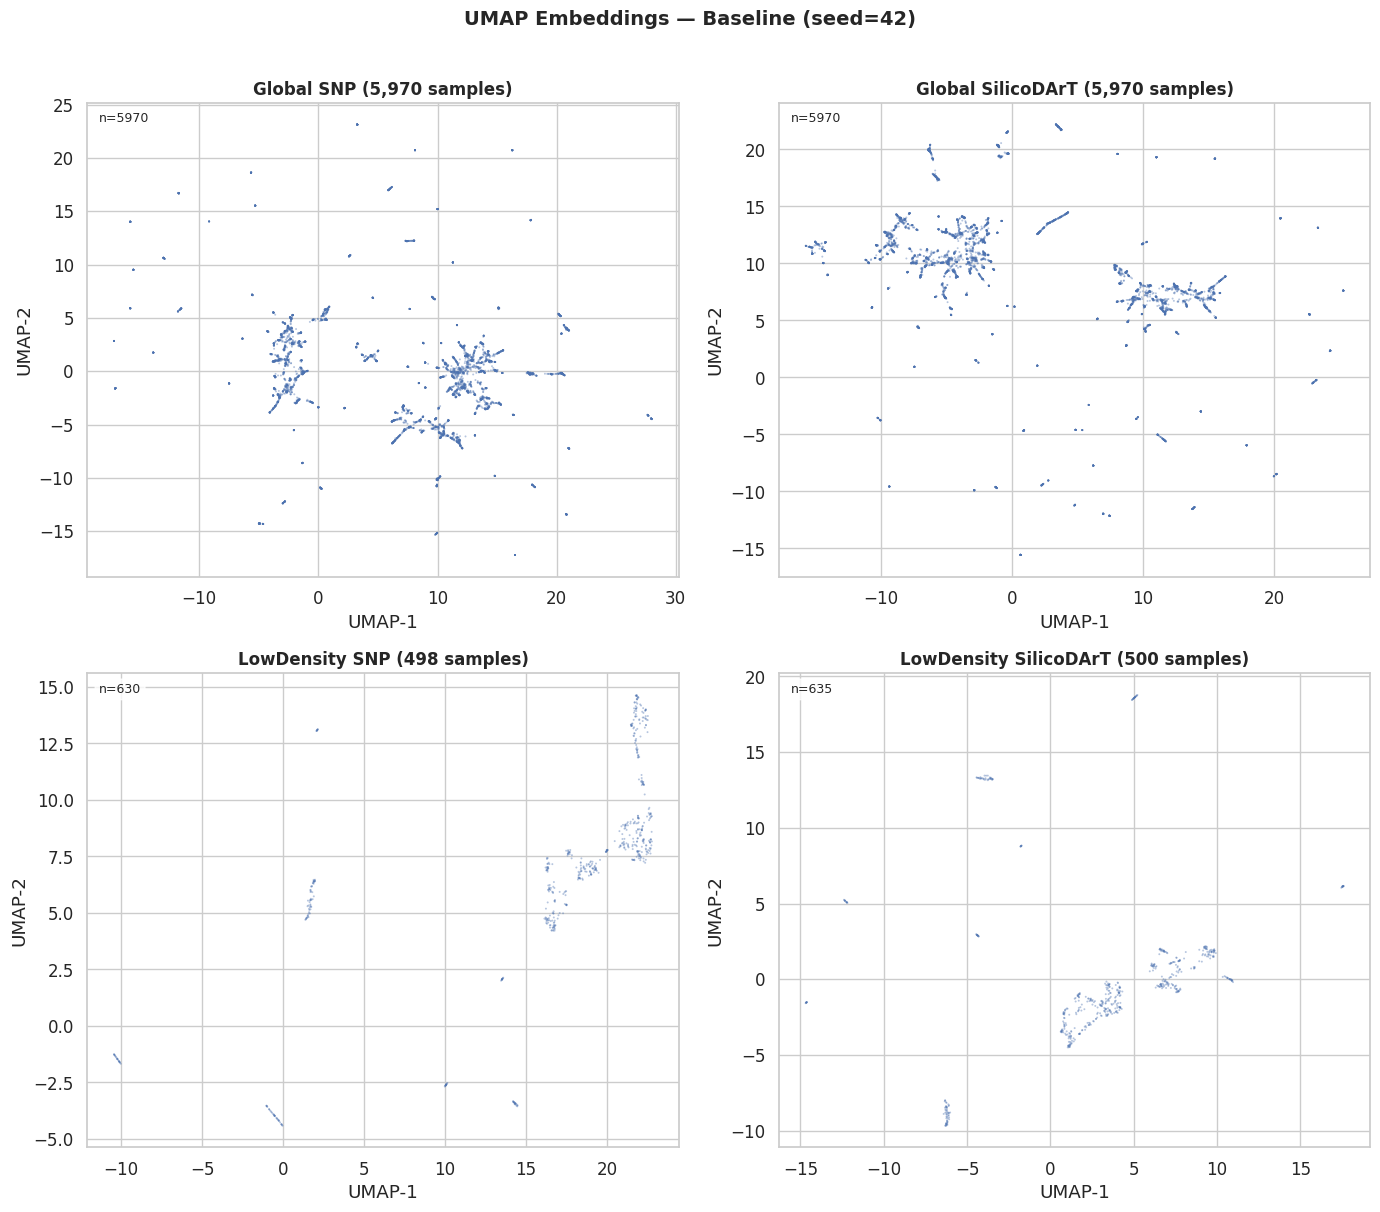

Saved → /shared/Code/OXOR/docs/figures/diagnostics/01_umap_scatter_all.png


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ds_labels = {
    "global_snp": "Global SNP (5,970 samples)",
    "global_silico": "Global SilicoDArT (5,970 samples)",
    "lowdensity_snp": "LowDensity SNP (498 samples)",
    "lowdensity_silico": "LowDensity SilicoDArT (500 samples)",
}

for ax, ds in zip(axes.flat, DATASETS):
    emb, ids, meta = load_nodes(ds, 42)
    ax.scatter(emb[:, 0], emb[:, 1], s=2, alpha=0.4, edgecolors="none")
    ax.set_title(ds_labels.get(ds, ds), fontsize=12, fontweight="bold")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    # Annotate sample count
    ax.text(0.02, 0.98, f"n={len(ids)}", transform=ax.transAxes,
            fontsize=9, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

fig.suptitle("UMAP Embeddings — Baseline (seed=42)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_umap_scatter_all.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / '01_umap_scatter_all.png'}")

## 2. Estabilidad entre seeds — ¿Los clusters se mantienen?

UMAP-Jaccard fue baja (~0.22). ¿Es porque la *topología global* cambia, o solo rotan/reflejan?  
Comparamos visualmente los 5 seeds del dataset más grande.

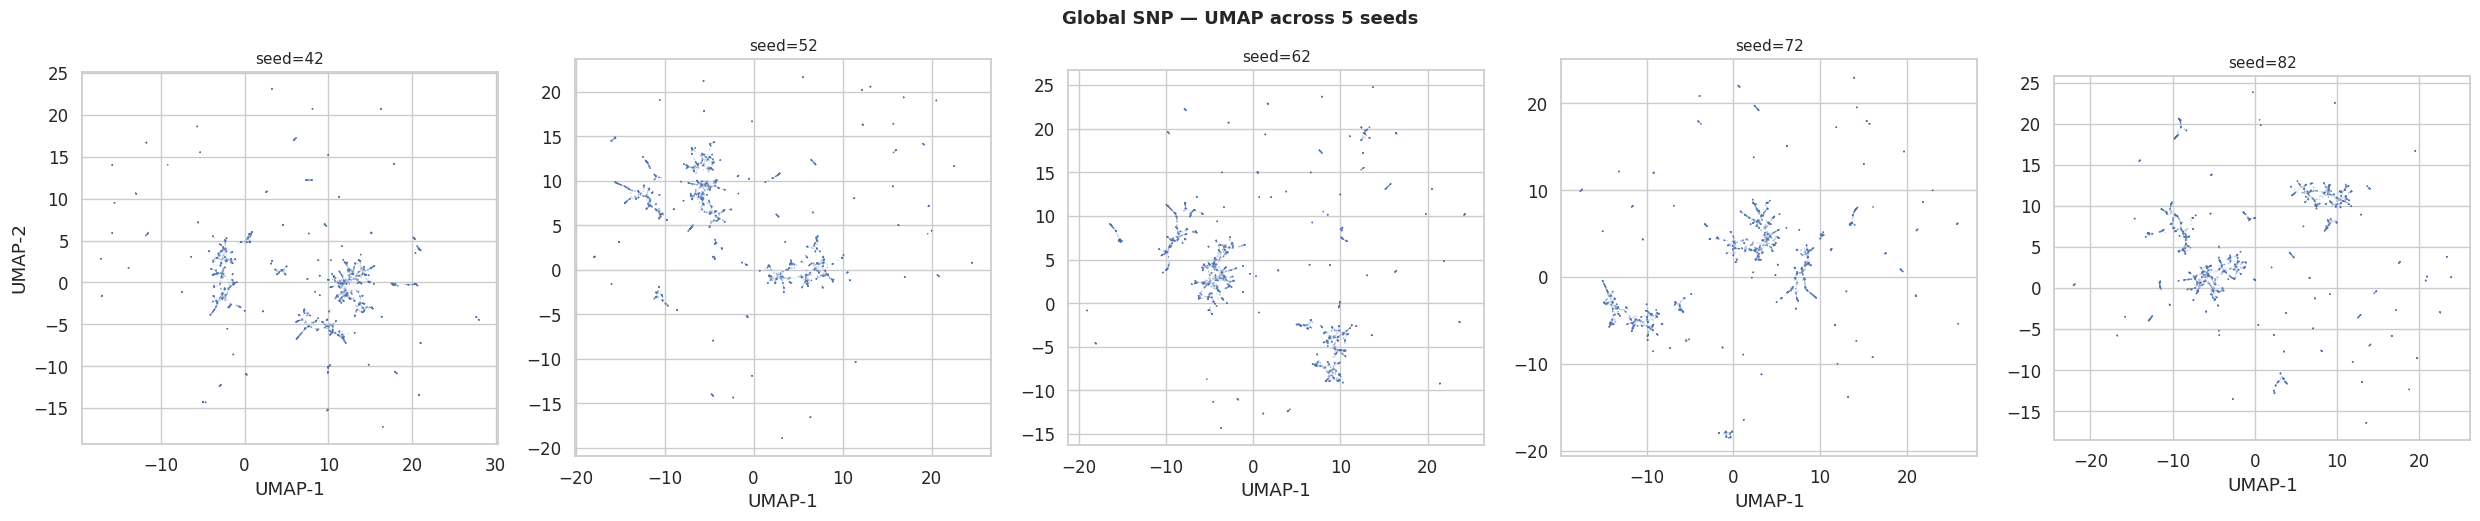

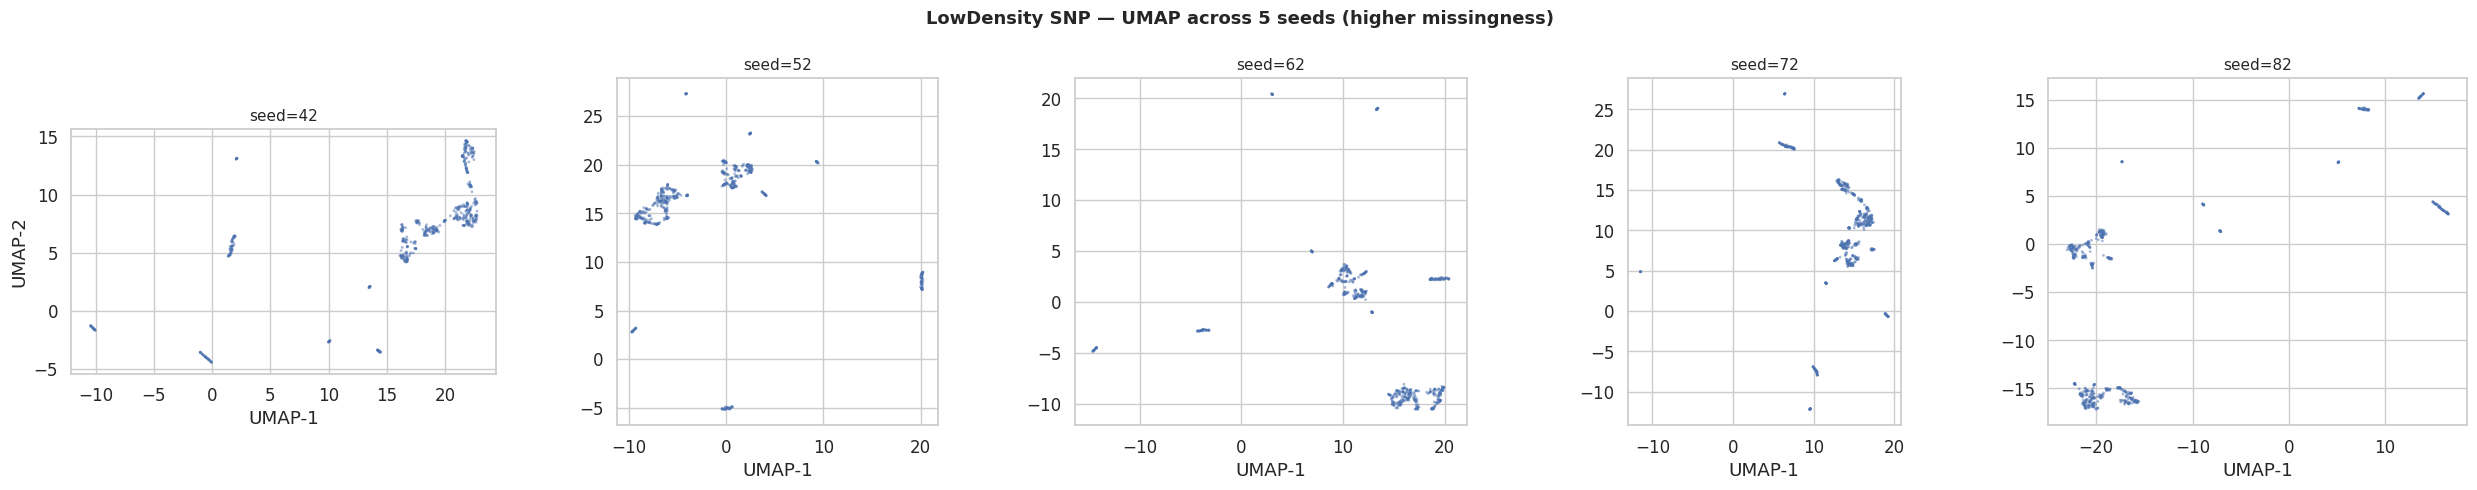

In [3]:
# Seed stability — global_snp (largest dataset)
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, seed in zip(axes, SEEDS):
    emb, ids, _ = load_nodes("global_snp", seed)
    ax.scatter(emb[:, 0], emb[:, 1], s=1, alpha=0.3, edgecolors="none")
    ax.set_title(f"seed={seed}", fontsize=11)
    ax.set_xlabel("UMAP-1")
    if seed == 42:
        ax.set_ylabel("UMAP-2")
    ax.set_aspect("equal")

fig.suptitle("Global SNP — UMAP across 5 seeds", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_seed_stability_global_snp.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Also for lowdensity_snp (higher missingness)
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, seed in zip(axes, SEEDS):
    emb, ids, _ = load_nodes("lowdensity_snp", seed)
    ax.scatter(emb[:, 0], emb[:, 1], s=4, alpha=0.5, edgecolors="none")
    ax.set_title(f"seed={seed}", fontsize=11)
    ax.set_xlabel("UMAP-1")
    if seed == 42:
        ax.set_ylabel("UMAP-2")
    ax.set_aspect("equal")

fig.suptitle("LowDensity SNP — UMAP across 5 seeds (higher missingness)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_seed_stability_lowdensity_snp.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 3. Density plots — ¿Distribución homogénea o hubs?

KDE 2D sobre el embedding para detectar concentraciones anómalas de muestras.

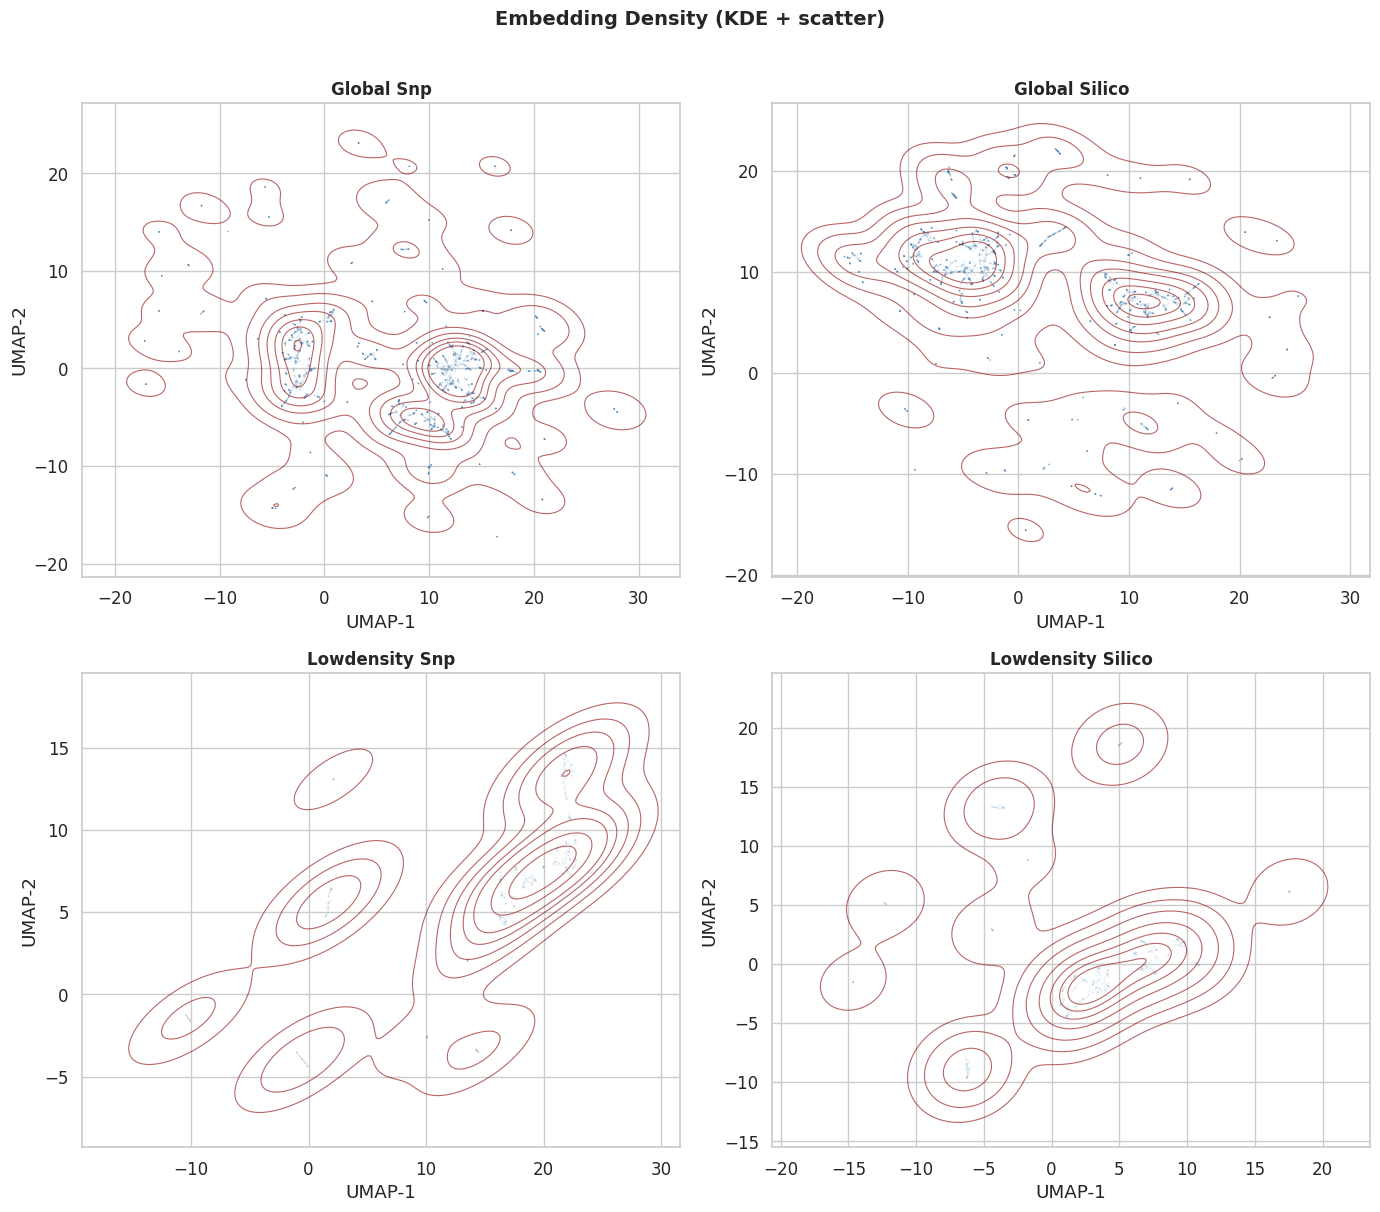

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, ds in zip(axes.flat, DATASETS):
    emb, ids, _ = load_nodes(ds, 42)
    # Scatter + KDE contours
    ax.scatter(emb[:, 0], emb[:, 1], s=1, alpha=0.15, color="steelblue", edgecolors="none")
    try:
        sns.kdeplot(x=emb[:, 0], y=emb[:, 1], ax=ax, levels=8, linewidths=0.8,
                    color="darkred", alpha=0.6)
    except Exception:
        pass
    ax.set_title(ds.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig.suptitle("Embedding Density (KDE + scatter)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_density_kde.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 4. PCA Scree Plot — Varianza explicada

¿La varianza está concentrada en pocos PCs (estructura fuerte) o distribuida (señal difusa)?  
Kaiser rule: PCs con eigenvalue > 1/p.

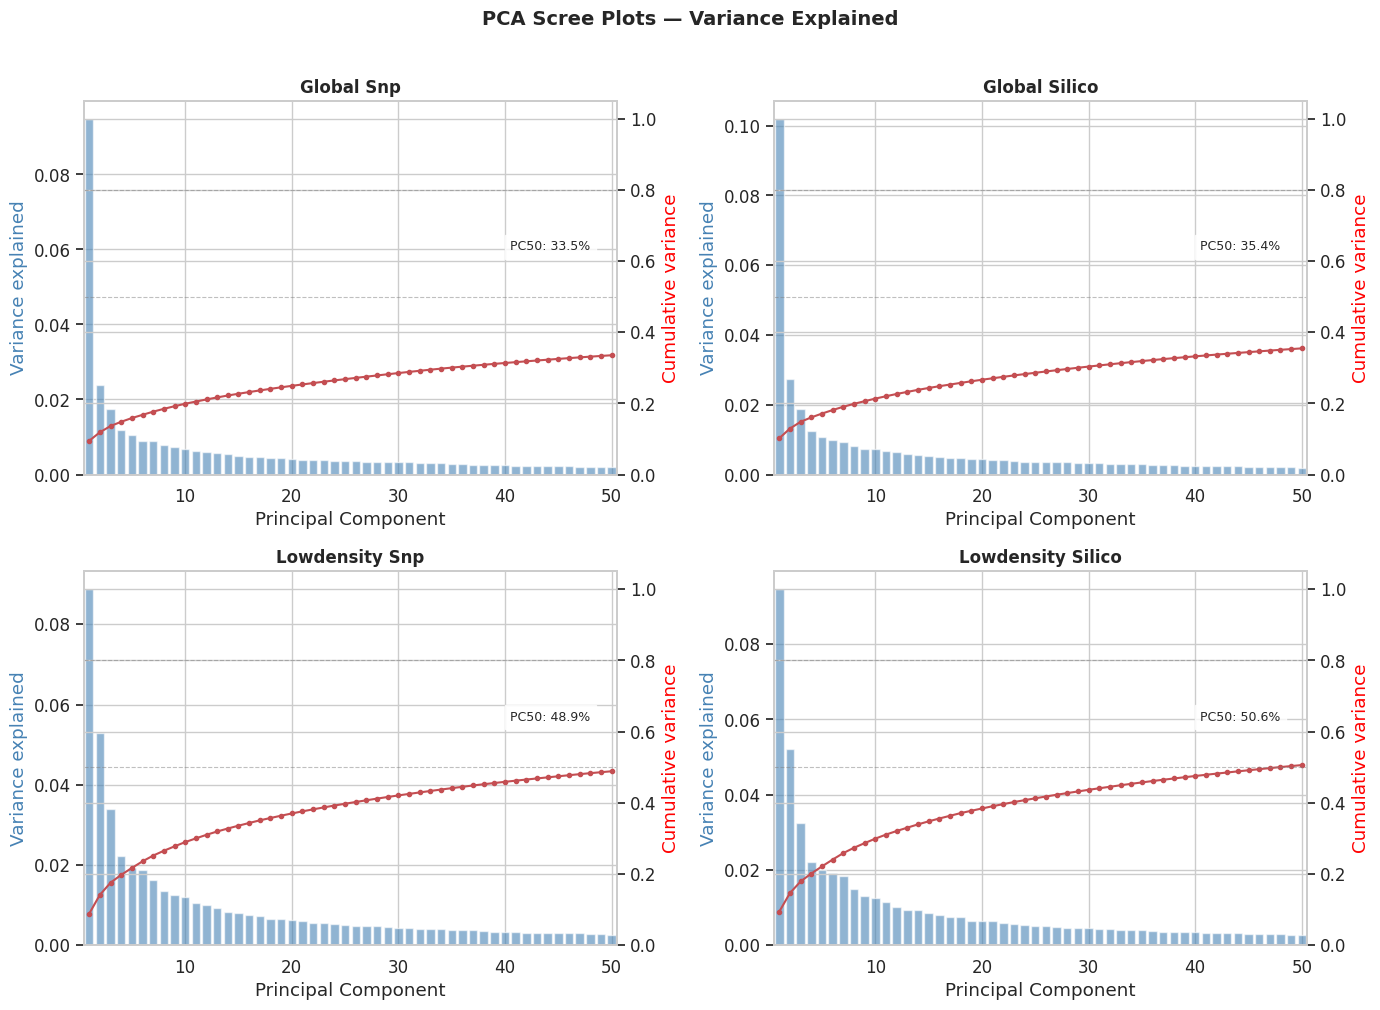

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, ds in zip(axes.flat, DATASETS):
    val = load_validation(ds)
    var_exp = val["pca_loadings"]["variance_explained"]
    cumvar = np.cumsum(var_exp)
    pcs = range(1, len(var_exp) + 1)

    color = "steelblue"
    ax.bar(pcs, var_exp, color=color, alpha=0.6, label="Individual")
    ax2 = ax.twinx()
    ax2.plot(pcs, cumvar, "r-o", markersize=3, linewidth=1.5, label="Cumulative")
    ax2.axhline(0.5, color="grey", linestyle="--", alpha=0.5, linewidth=0.8)
    ax2.axhline(0.8, color="grey", linestyle="--", alpha=0.5, linewidth=0.8)
    ax2.set_ylabel("Cumulative variance", color="red")
    ax2.set_ylim(0, 1.05)

    ax.set_title(ds.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance explained", color=color)
    ax.set_xlim(0.5, min(50, len(var_exp)) + 0.5)

    # Annotate PC50 cumulative
    if len(cumvar) >= 50:
        ax.text(0.95, 0.6, f"PC50: {cumvar[49]:.1%}", transform=ax.transAxes,
                fontsize=9, ha="right", bbox=dict(fc="white", alpha=0.8))

fig.suptitle("PCA Scree Plots — Variance Explained", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_pca_scree.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 5. Degree distribution kNN — ¿Hubs o grafo homogéneo?

En un k-NN dirigido todos tienen degree-out = k, pero el degree-in varía.  
Si hay nodos con in-degree muy alto → son "hubs" que pueden distorsionar el embedding.

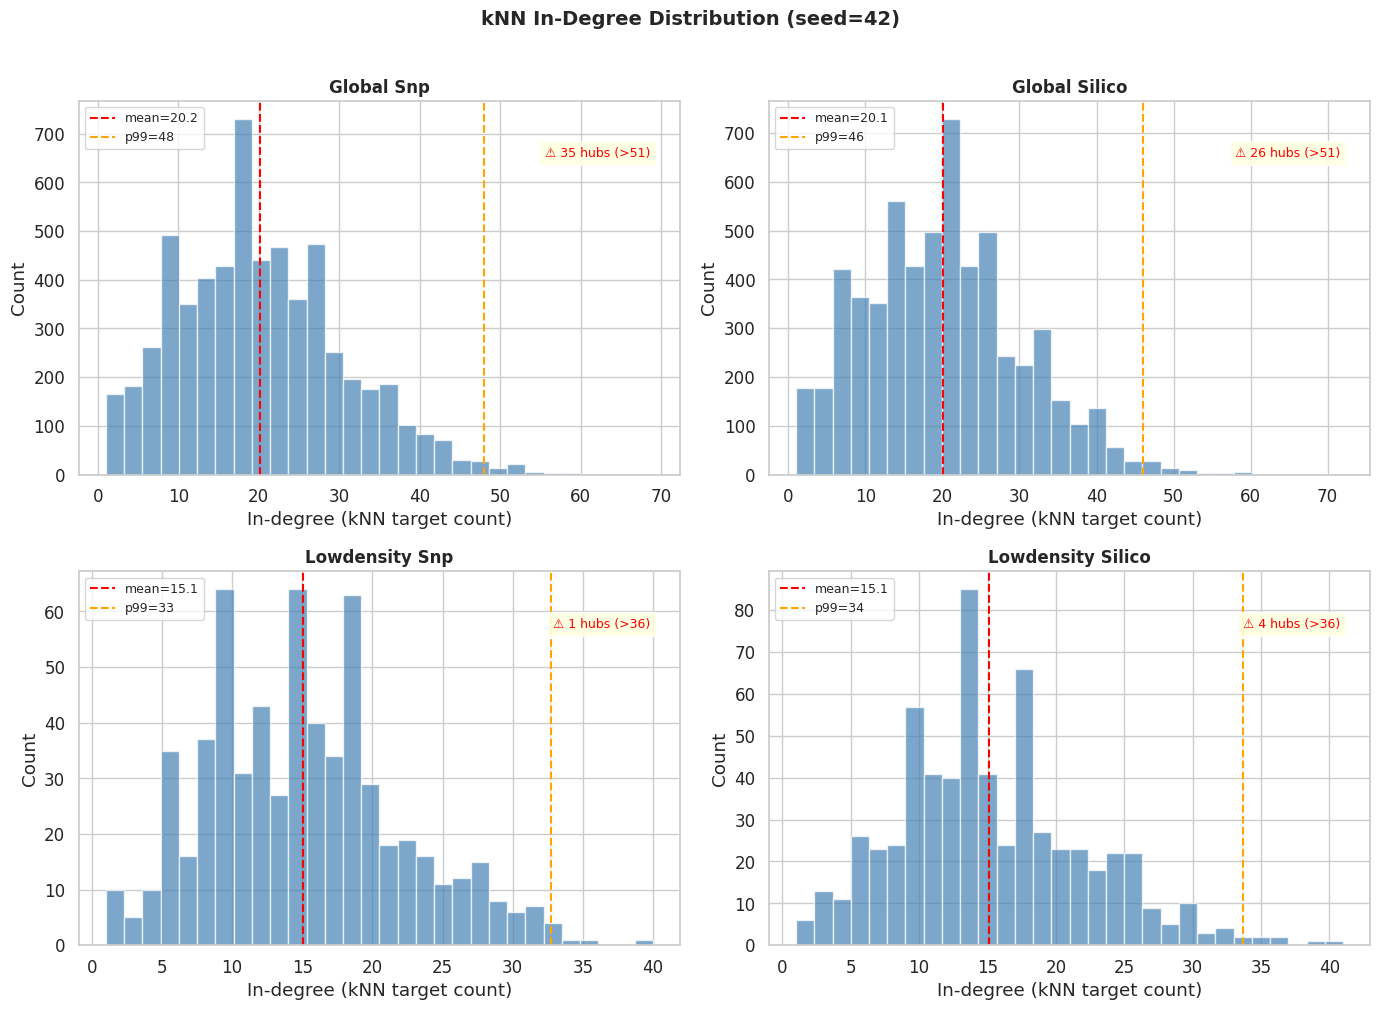

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, ds in zip(axes.flat, DATASETS):
    edges = load_edges(ds, 42)
    # In-degree: how many times a node appears as target
    in_deg = Counter(e["target"] for e in edges)
    degrees = list(in_deg.values())

    ax.hist(degrees, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(np.mean(degrees), color="red", linestyle="--", linewidth=1.5,
               label=f"mean={np.mean(degrees):.1f}")
    ax.axvline(np.percentile(degrees, 99), color="orange", linestyle="--",
               linewidth=1.5, label=f"p99={np.percentile(degrees, 99):.0f}")
    ax.set_title(ds.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xlabel("In-degree (kNN target count)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

    # Flag potential hubs
    hub_thresh = np.mean(degrees) + 3 * np.std(degrees)
    n_hubs = sum(1 for d in degrees if d > hub_thresh)
    if n_hubs:
        ax.text(0.95, 0.85, f"⚠ {n_hubs} hubs (>{hub_thresh:.0f})",
                transform=ax.transAxes, fontsize=9, ha="right", color="red",
                bbox=dict(fc="lightyellow", alpha=0.9))

fig.suptitle("kNN In-Degree Distribution (seed=42)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_knn_degree_dist.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 6. Outliers — Muestras extremas en el embedding

Detectar muestras que estén > 3σ del centroide. Pueden ser errores de laboratorio, contaminación, o diversidad real.

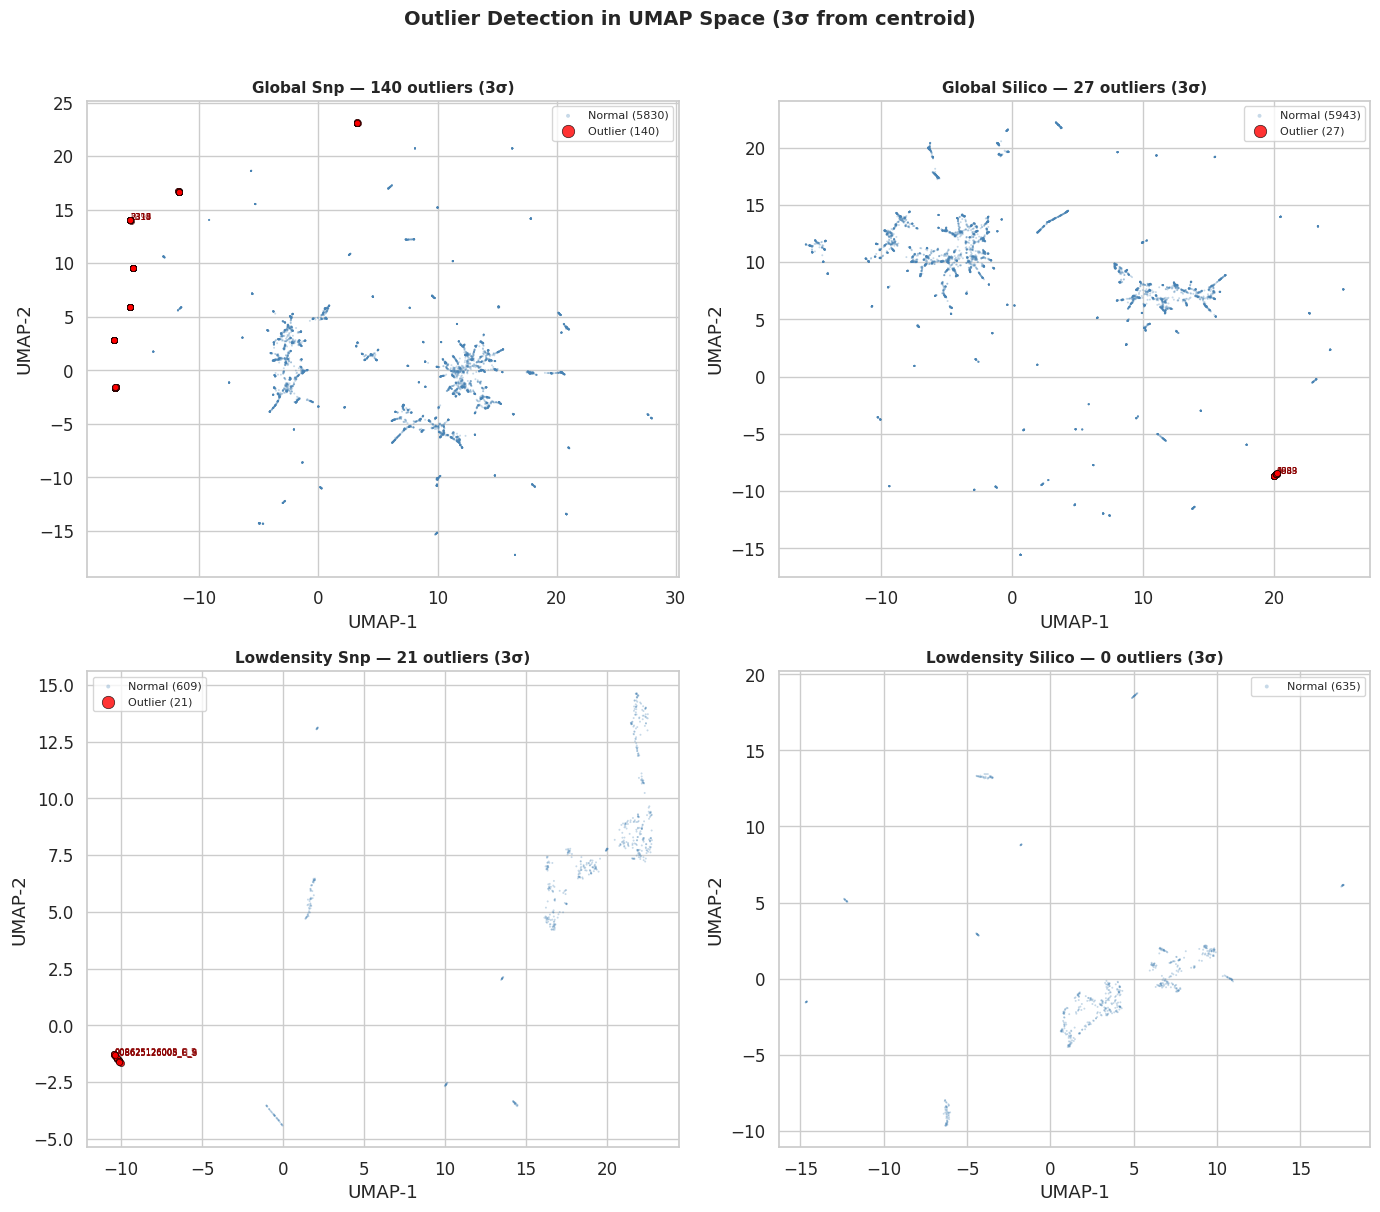

global_snp: 140 outliers (2.3%), thresh=23.24
  Top IDs: ['198', '272', '202', '356', '329', '406', '610', '663', '778', '904']
global_silico: 27 outliers (0.5%), thresh=24.59
  Top IDs: ['149', '261', '253', '262', '251', '252', '965', '970', '963', '1003']
lowdensity_snp: 21 outliers (3.3%), thresh=25.56
  Top IDs: ['908625126005_A_8', '908625126005_A_9', '908625126005_B_9', '908625126005_C_8', '908625126005_C_9', '908625126005_D_8', '908625126005_E_8', '908625126005_E_9', '908625126005_F_9', '908625126005_G_8']
lowdensity_silico: 0 outliers (0.0%), thresh=21.35


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

outlier_report = {}

for ax, ds in zip(axes.flat, DATASETS):
    emb, ids, meta = load_nodes(ds, 42)
    centroid = emb.mean(axis=0)
    dists = np.linalg.norm(emb - centroid, axis=1)
    thresh = dists.mean() + 3 * dists.std()

    is_outlier = dists > thresh
    n_outliers = is_outlier.sum()

    ax.scatter(emb[~is_outlier, 0], emb[~is_outlier, 1], s=2, alpha=0.3,
               color="steelblue", edgecolors="none", label=f"Normal ({(~is_outlier).sum()})")
    if n_outliers:
        ax.scatter(emb[is_outlier, 0], emb[is_outlier, 1], s=20, alpha=0.8,
                   color="red", edgecolors="black", linewidths=0.5,
                   label=f"Outlier ({n_outliers})", zorder=5)
        # Label top 5 outliers
        top_idx = np.argsort(dists)[-min(5, n_outliers):]
        for i in top_idx:
            ax.annotate(ids[i], (emb[i, 0], emb[i, 1]), fontsize=6,
                        color="darkred", alpha=0.8)

    ax.set_title(f"{ds.replace('_', ' ').title()} — {n_outliers} outliers (3σ)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=8, markerscale=2)

    outlier_ids = [ids[i] for i in np.where(is_outlier)[0]]
    outlier_report[ds] = {
        "n_outliers": n_outliers,
        "pct": f"{n_outliers / len(ids) * 100:.1f}%",
        "threshold": f"{thresh:.2f}",
        "ids": outlier_ids[:10],
    }

fig.suptitle("Outlier Detection in UMAP Space (3σ from centroid)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_outliers.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Print report
for ds, rep in outlier_report.items():
    print(f"{ds}: {rep['n_outliers']} outliers ({rep['pct']}), thresh={rep['threshold']}")
    if rep["ids"]:
        print(f"  Top IDs: {rep['ids']}")

## 7. Edge distance distribution — ¿El grafo tiene escala consistente?

Distribución de distancias de las aristas kNN. Si hay bimodalidad → posibles sub-poblaciones desconectadas.

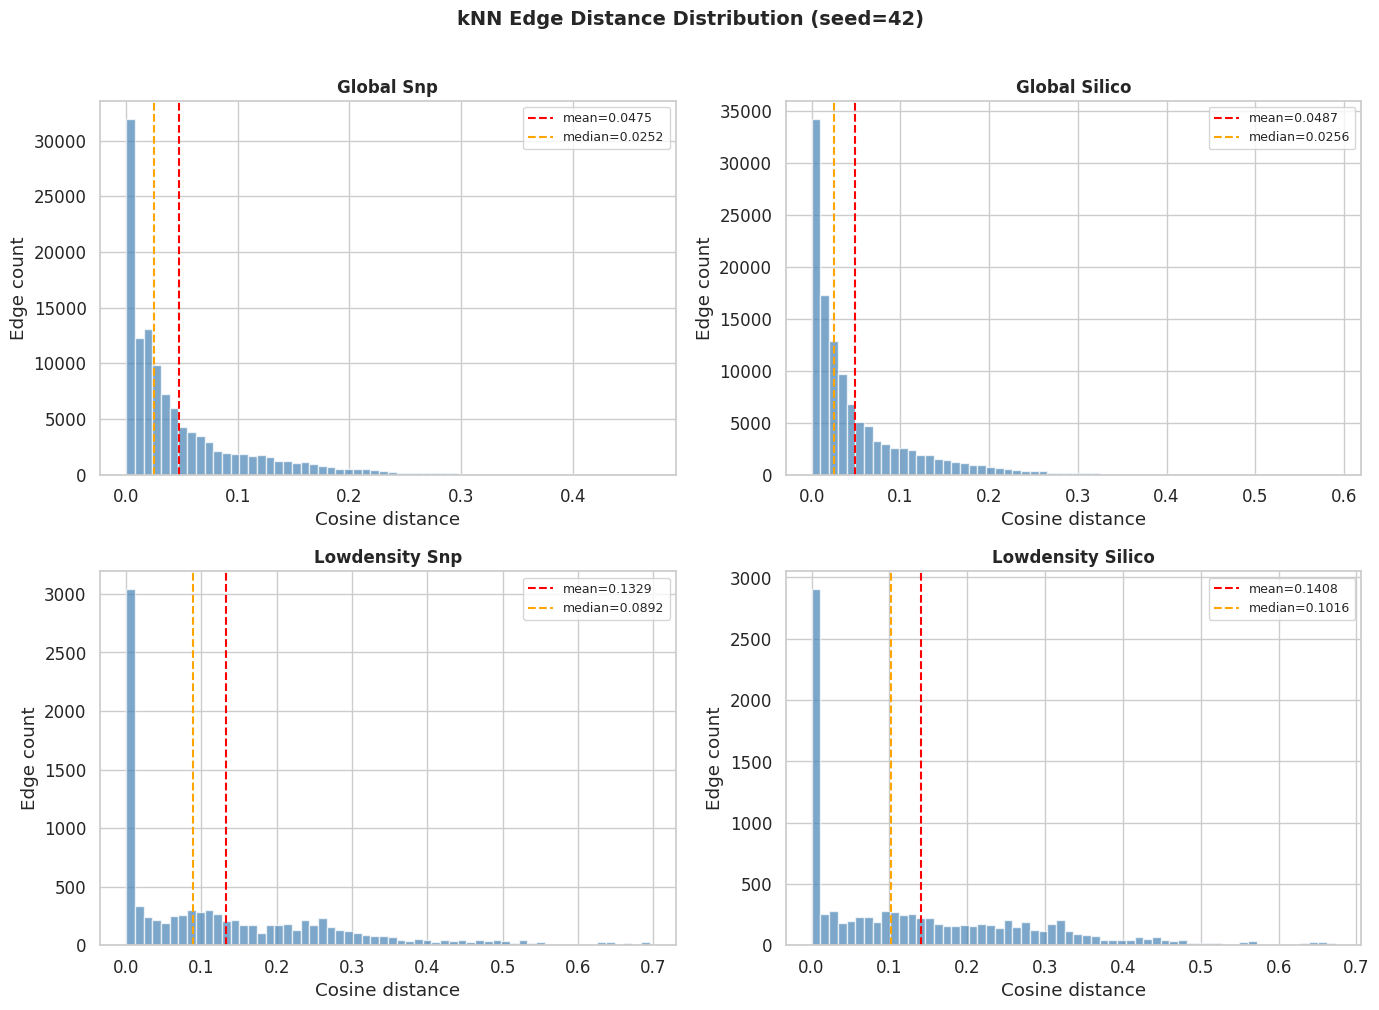

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, ds in zip(axes.flat, DATASETS):
    edges = load_edges(ds, 42)
    dists = [e["distance"] for e in edges]

    ax.hist(dists, bins=60, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(np.mean(dists), color="red", linestyle="--",
               label=f"mean={np.mean(dists):.4f}")
    ax.axvline(np.median(dists), color="orange", linestyle="--",
               label=f"median={np.median(dists):.4f}")
    ax.set_title(ds.replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Edge count")
    ax.legend(fontsize=9)

fig.suptitle("kNN Edge Distance Distribution (seed=42)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_edge_distance_dist.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 8. Resumen de métricas — Tabla comparativa

Vista consolidada de todos los diagnósticos numéricos para referencia rápida.

In [9]:
rows = []
for ds in DATASETS:
    val = load_validation(ds)
    t = val["trustworthiness"]
    s = val.get("stability") or {}
    pca = val["pca_loadings"]
    emb, ids, _ = load_nodes(ds, 42)
    edges = load_edges(ds, 42)
    dists_arr = [e["distance"] for e in edges]

    # Outlier count
    centroid = emb.mean(axis=0)
    d = np.linalg.norm(emb - centroid, axis=1)
    n_out = (d > d.mean() + 3*d.std()).sum()

    rows.append({
        "Dataset": ds,
        "Samples": val["shape"][0],
        "Markers": val["shape"][1],
        "Trust (μ±σ)": f"{t['mean']:.4f} ± {t['std']:.4f}",
        "PCA-J": f"{s.get('pca_neighbour_jaccard_mean', 'N/A'):.4f}" if s else "N/A",
        "UMAP-J": f"{s.get('umap_neighbour_jaccard_mean', 'N/A'):.4f}" if s else "N/A",
        "PCA var(5)": f"{pca['cumulative_variance_5pc']:.1%}",
        "Edge dist μ": f"{np.mean(dists_arr):.4f}",
        "Outliers (3σ)": n_out,
    })

summary_df = pd.DataFrame(rows)
display(summary_df.style.set_caption("Baseline poster-v2 — Summary").hide(axis="index"))

Dataset,Samples,Markers,Trust (μ±σ),PCA-J,UMAP-J,PCA var(5),Edge dist μ,Outliers (3σ)
global_snp,5970,20069,0.9756 ± 0.0017,0.8869,0.2192,15.9%,0.0475,140
global_silico,5970,57715,0.9792 ± 0.0006,0.8982,0.2211,17.1%,0.0487,27
lowdensity_snp,630,62732,0.9334 ± 0.0018,0.9123,0.2848,21.7%,0.1329,21
lowdensity_silico,635,38272,0.9105 ± 0.0046,0.9128,0.2107,22.2%,0.1408,0
